# Exploratory Data Analysis on Retail Sales Dataset

## Objective

This project analyzes over 1 million retail transactions to uncover:

- Revenue distribution patterns
- Seasonal demand trends
- Product performance insights
- Customer segmentation using RFM analysis
- Customer retention behavior through cohort analysis
- Operational impact of product returns

The goal is to translate transactional data into actionable business insights.

<h1><u>STEP 1: Data Loading & Initial Inspection</u></h1>

In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For better visualization
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [196]:
df = pd.read_csv("../data/raw_data.csv", encoding="ISO-8859-1")

## Data Overview

The dataset contains transactional-level retail data including:

- Invoice information
- Product details
- Quantity and price
- Customer identifiers
- Transaction timestamps
- Country information

Each row represents a single product transaction within an invoice.

In [197]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [198]:
df.shape

(1067371, 8)

In [199]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [200]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [201]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

<h1><u>STEP 2: Data Cleaning & Feature Engineering</u></h1>

In [202]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate']) # Converting InvoiceDate to datetime
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [203]:
df_sales = df[(df['Quantity'] > 0) & (df['Price'] > 0)].copy() # For revenue trend analysis, we focus only on actual sales

In [204]:
df_sales['Revenue'] = df_sales['Quantity'] * df_sales['Price'] # Creating Revenue Column

In [205]:
# Creating time features
df_sales['Month'] = df_sales['InvoiceDate'].dt.month
df_sales['Quarter'] = df_sales['InvoiceDate'].dt.quarter
df_sales['DayOfWeek'] = df_sales['InvoiceDate'].dt.day_name()
df_sales['Year'] = df_sales['InvoiceDate'].dt.year

In [206]:
# Creating Customer Dataset (For Segmentation)
df_customer = df_sales.dropna(subset=['Customer ID']).copy()

In [207]:
df_sales.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month,Quarter,DayOfWeek,Year
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,12,4,Tuesday,2009
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,12,4,Tuesday,2009
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,12,4,Tuesday,2009
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,12,4,Tuesday,2009
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,12,4,Tuesday,2009


In [208]:
df_customer.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Month,Quarter,DayOfWeek,Year
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,12,4,Tuesday,2009
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,12,4,Tuesday,2009
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,12,4,Tuesday,2009
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,12,4,Tuesday,2009
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,12,4,Tuesday,2009


In [209]:
print("Original df shape:", df.shape)
print("Sales dataset shape:", df_sales.shape)
print("Customer dataset shape:", df_customer.shape)

Original df shape: (1067371, 8)
Sales dataset shape: (1041671, 13)
Customer dataset shape: (805549, 13)


## Data Cleaning & Preparation

To ensure analytical accuracy:

- Removed transactions with negative quantities and prices for revenue analysis.
- Created a Revenue variable (Quantity × Price).
- Converted InvoiceDate to datetime format.
- Created separate datasets for sales and customer-level analysis.
- Preserved return transactions for separate operational analysis.

This ensures accurate revenue, seasonal, and segmentation insights.

<h1><u>STEP 3: Univariate Analysis</u></h1>

<h2><u>Revenue Distribution</u></h2>

In [210]:
df_sales['Revenue'].describe()

count    1.041671e+06
mean     2.013397e+01
std      2.031167e+02
min      1.000000e-03
25%      3.900000e+00
50%      9.960000e+00
75%      1.770000e+01
max      1.684696e+05
Name: Revenue, dtype: float64

* 75% of revenue ≤ 17.7

* Median ≈ 9.6

* Max = 168,496

That’s MASSIVE skew!

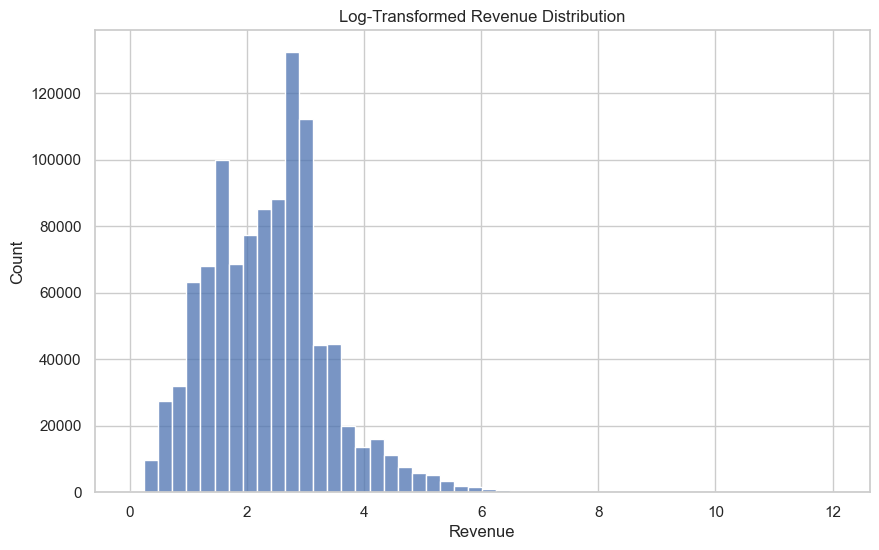

In [211]:
plt.figure()
sns.histplot(np.log1p(df_sales['Revenue']), bins=50)
plt.title("Log-Transformed Revenue Distribution")
plt.savefig("../visuals/log_transformed_revenue_distribution.png", dpi=300)

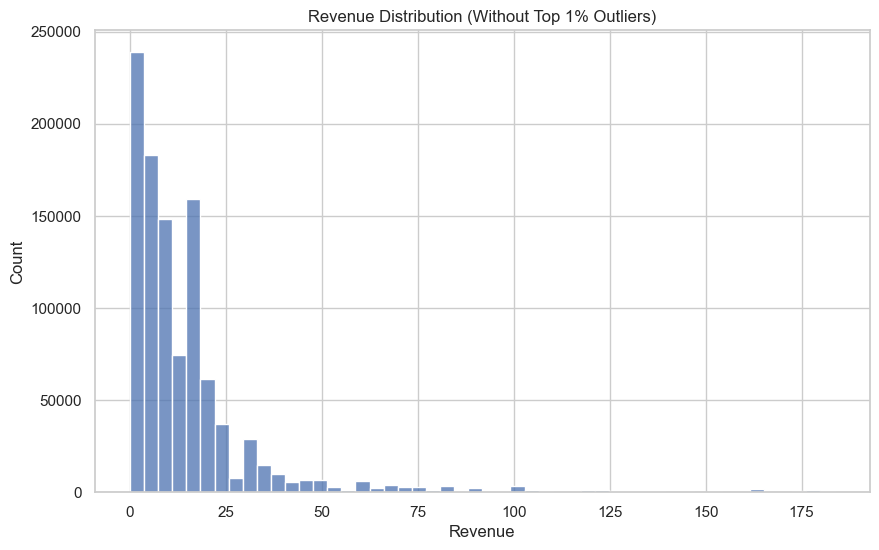

In [212]:
upper_limit = df_sales['Revenue'].quantile(0.99)

df_trimmed = df_sales[df_sales['Revenue'] <= upper_limit]

plt.figure()
sns.histplot(df_trimmed['Revenue'], bins=50)
plt.title("Revenue Distribution (Without Top 1% Outliers)")
plt.savefig("../visuals/revenue_distribution2.png", dpi=300)

## Revenue Distribution Analysis

Revenue distribution is highly right-skewed.

- Most transactions involve small purchase values.
- A small number of bulk transactions contribute disproportionately large revenue.
- Log transformation reveals near-normal distribution behavior.

This indicates a mix of regular retail buyers and high-volume customers.

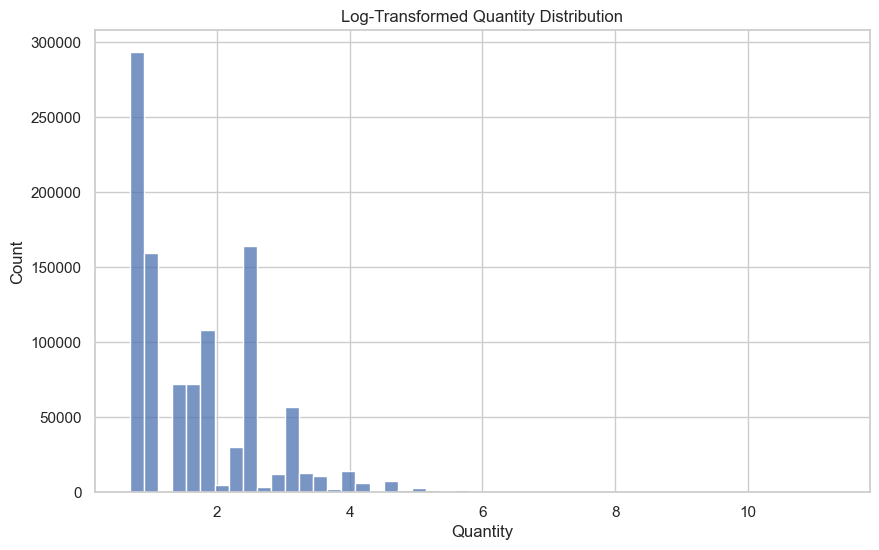

In [213]:
plt.figure()
sns.histplot(np.log1p(df_sales['Quantity']), bins=50)
plt.title("Log-Transformed Quantity Distribution")
plt.savefig("../visuals/log_transformed_quantity_distribution.png", dpi=300)

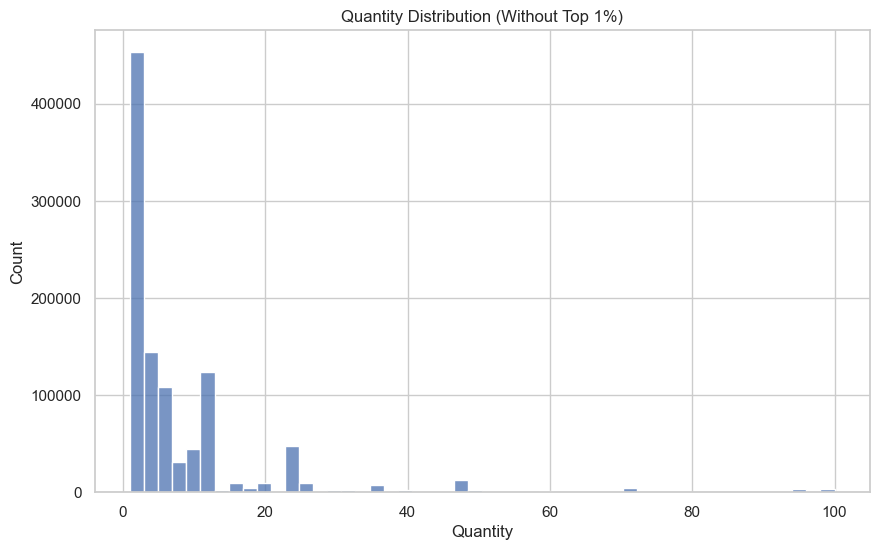

In [214]:
upper_limit = df_sales['Quantity'].quantile(0.99)

df_trim = df_sales[df_sales['Quantity'] <= upper_limit]

plt.figure()
sns.histplot(df_trim['Quantity'], bins=50)
plt.title("Quantity Distribution (Without Top 1%)")
plt.savefig("../visuals/quantity_distribution.png", dpi=300)

In [215]:
top_countries = df_sales.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
top_countries

Country
United Kingdom    1.787135e+07
EIRE              6.644318e+05
Netherlands       5.542323e+05
Germany           4.312625e+05
France            3.569446e+05
Australia         1.699681e+05
Spain             1.091785e+05
Switzerland       1.010113e+05
Sweden            9.190372e+04
Denmark           6.986219e+04
Name: Revenue, dtype: float64

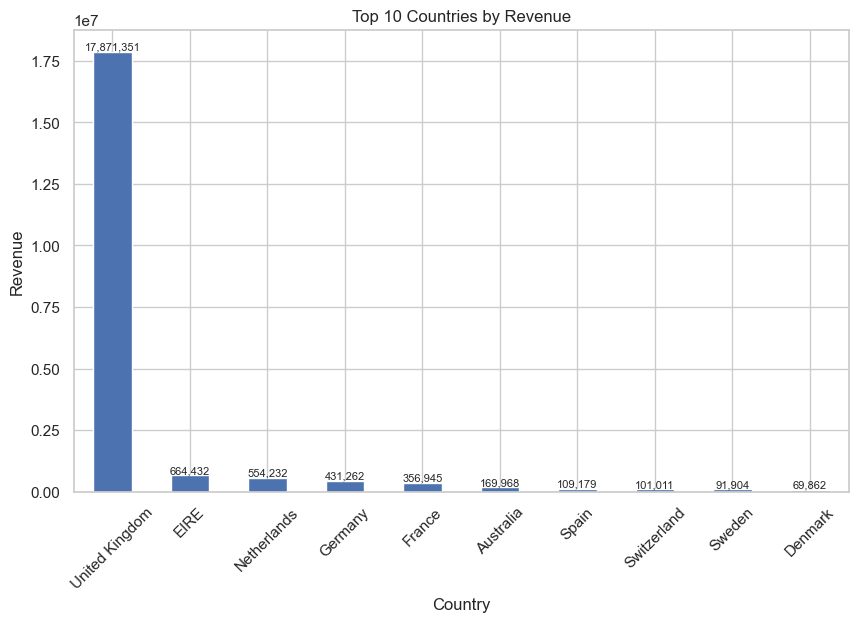

In [216]:
# Top 10 countries by revenue
plt.figure()

ax = top_countries.plot(kind='bar')

plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

# Add value labels
for i, value in enumerate(top_countries):
    ax.text(i, value, f'{value:,.0f}', ha='center', va='bottom', fontsize=8)


plt.savefig("../visuals/top10_country_revenue.png", dpi=300)

From the table and chart above


<b><u>Observations</b></u>:

<b>Top performing countries by revenue</b>

| Country           | Revenue        |
|------------------|---------------:|
| United Kingdom   | 17,871,350     |
| EIRE             |    664,431.80  |
| Netherlands      |    554,232.30  |
| Germany          |    431,262.50  |
| France           |    356,944.60  |
| Australia        |    169,968.10  |
| Spain            |    109,178.50  |
| Switzerland      |    101,011.30  |
| Sweden           |     91,903.72  |
| Denmark          |     69,862.19  |


<b>With UK being the most revenue generating country, generating almost 85% of the revenue</b>


In [217]:
country_share = df_sales.groupby('Country')['Revenue'].sum()
country_percentage = (country_share / country_share.sum()) * 100
country_percentage.sort_values(ascending=False).head(5)

Country
United Kingdom    85.211360
EIRE               3.168039
Netherlands        2.642603
Germany            2.056278
France             1.701927
Name: Revenue, dtype: float64

In [218]:
top_products = df_sales.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
top_products

Description
REGENCY CAKESTAND 3 TIER              344563.25
Manual                                341104.90
DOTCOM POSTAGE                        322657.48
WHITE HANGING HEART T-LIGHT HOLDER    266923.55
PAPER CRAFT , LITTLE BIRDIE           168469.60
JUMBO BAG RED RETROSPOT               150935.56
PARTY BUNTING                         149187.05
ASSORTED COLOUR BIRD ORNAMENT         132187.92
POSTAGE                               127597.42
PAPER CHAIN KIT 50'S CHRISTMAS        123141.54
Name: Revenue, dtype: float64

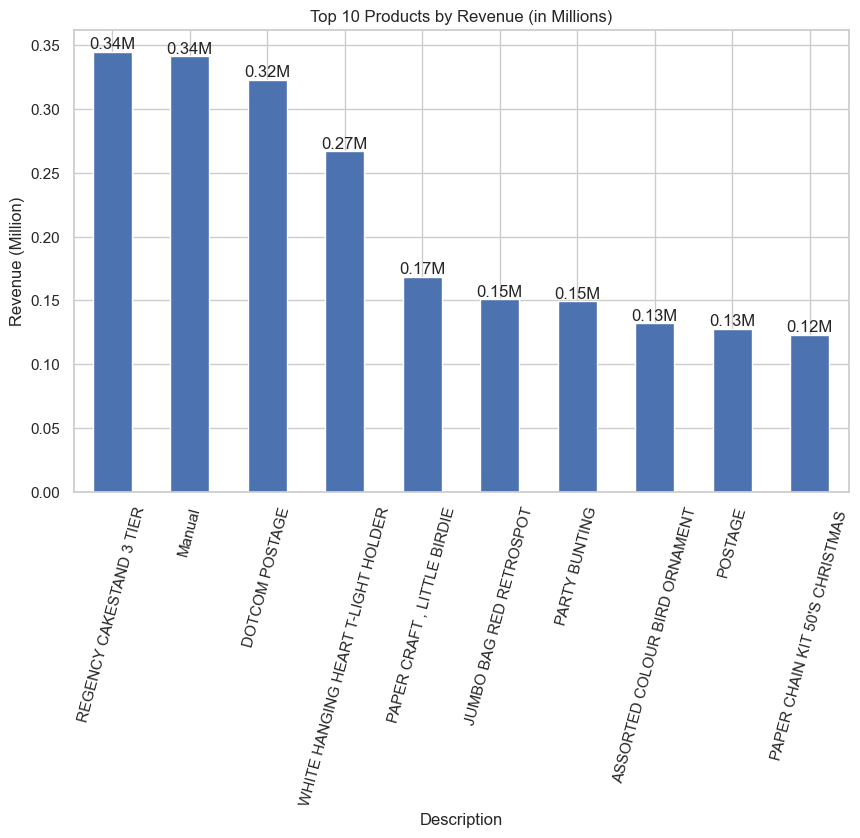

In [219]:
top_products_million = top_products / 1_000_000

plt.figure()
ax = top_products_million.plot(kind='bar')

plt.title("Top 10 Products by Revenue (in Millions)")
plt.ylabel("Revenue (Million)")
plt.xticks(rotation=75)

for i, value in enumerate(top_products_million):
    ax.text(i, value, f'{value:.2f}M', ha='center', va='bottom')


plt.savefig("../visuals/top10_product_revenue.png", dpi=300)

From the table and chart above 

<b><u>Observations</b></u>:

<b>Top performing products by revenue</b>

 Product Name                          | Revenue     |
|----------------------------------------|------------:|
| REGENCY CAKESTAND 3 TIER              | 344563.25   |
| Manual                                | 341104.90   |
| DOTCOM POSTAGE                        | 322657.48   |
| WHITE HANGING HEART T-LIGHT HOLDER    | 266923.55   |
| PAPER CRAFT , LITTLE BIRDIE           | 168469.60   |
| JUMBO BAG RED RETROSPOT               | 150935.56   |
| PARTY BUNTING                         | 149187.05   |
| ASSORTED COLOUR BIRD ORNAMENT         | 132187.92   |
| POSTAGE                               | 127597.42   |
| PAPER CHAIN KIT 50'S CHRISTMAS        | 123141.54   |

<h1><u>STEP 4: Seasonal Trend Analysis</u></h1>

In [220]:
monthly_revenue = df_sales.groupby(['Year','Month'])['Revenue'].sum().reset_index()

In [221]:
monthly_revenue['YearMonth'] = pd.to_datetime(monthly_revenue['Year'].astype(str) + '-' + monthly_revenue['Month'].astype(str)) # Creating a date column for plotting

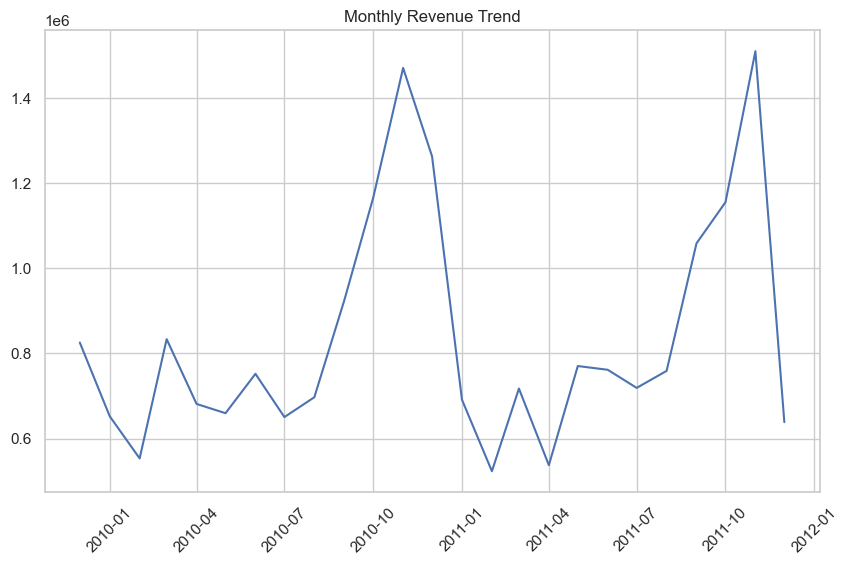

In [222]:
plt.figure()
plt.plot(monthly_revenue['YearMonth'], monthly_revenue['Revenue'])
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)

plt.savefig("../visuals/monthly_revenue_trend.png", dpi=300)

From the plot:

* Strong Q4 Spike (Both Years)

* Oct–Nov 2010 --> strong rise

* Oct–Nov 2011 --> even stronger rise

<b>That’s classic retail seasonality.<b>

<b><u>Likely reasons</u></b>:

1. Christmas

2. Holiday shopping

3. Corporate bulk purchases

So yes, Q4 is clearly stronger.


<b><u>Sharp Drop in December 2011</u></b>

We see a huge drop at the end.This is NOT a real business crash.This dataset ends around early/mid December 2011.So December 2011 is incomplete. That’s why revenue looks lower.


<b><u>Pattern Across Years</b></u>


* Early 2010 --> moderate

* Mid 2010 --> stable

* Q4 2010 --> spike

* Early 2011 --> drop again

* Q4 2011 --> spike again

<b><u>Observation</b></u>:

Strong yearly seasonality cycle


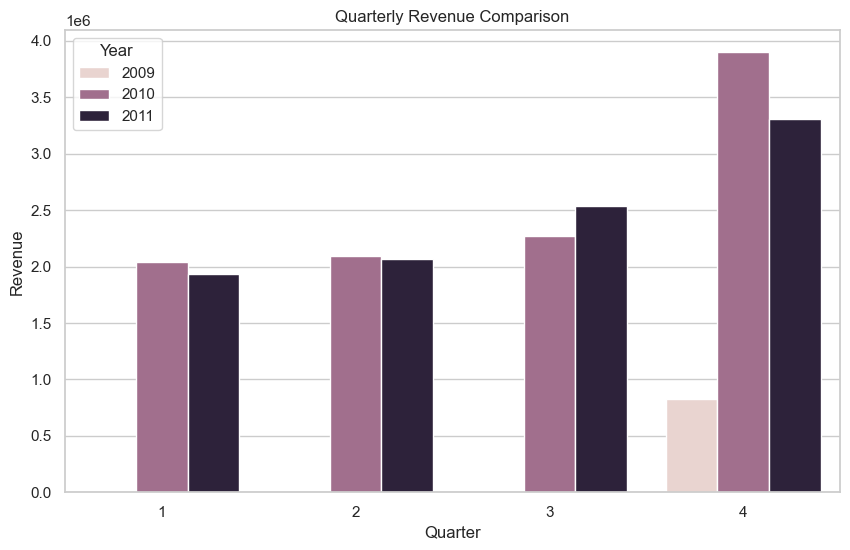

In [223]:
quarterly_revenue = df_sales.groupby(['Year','Quarter'])['Revenue'].sum().reset_index()

plt.figure()
sns.barplot(data=quarterly_revenue, x='Quarter', y='Revenue', hue='Year')
plt.title("Quarterly Revenue Comparison")

plt.savefig("../visuals/quarterly_revenue_comparison.png", dpi=300)

## Seasonal Trend Analysis

Revenue demonstrates strong recurring Q4 spikes, particularly in November.

- Clear holiday-driven demand pattern.
- Seasonal cycle repeats across years.
- December 2011 decline reflects incomplete data rather than true demand drop.

Business operations should prepare for strong Q4 inventory and marketing demand.

<h1><u>STEP 5: Customer Segmentation Analysis</u></h1>

In [224]:
# Creating Customer-Level Summary Table
customer_summary = df_customer.groupby('Customer ID').agg({
    'Revenue': 'sum',
    'Invoice': 'nunique',
    'Quantity': 'sum'
}).reset_index()

customer_summary.columns = ['CustomerID', 'TotalSpend', 'TotalOrders', 'TotalQuantity']

customer_summary.head()

,CustomerID,TotalSpend,TotalOrders,TotalQuantity
0,12346.0,77556.46,12,74285
1,12347.0,5633.32,8,3286
2,12348.0,2019.40,5,2714
3,12349.0,4428.69,4,1624
4,12350.0,334.40,1,197


In [225]:
customer_summary.describe()

,CustomerID,TotalSpend,TotalOrders,TotalQuantity
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,3018.616737,6.289384,1821.396223
std,1715.572666,14737.731040,13.009406,8963.011855
min,12346.000000,2.950000,1.000000,1.000000
25%,13833.250000,348.762500,1.000000,190.000000
50%,15314.500000,898.915000,3.000000,491.500000
75%,16797.750000,2307.090000,7.000000,1376.000000
max,18287.000000,608821.650000,398.000000,367193.000000


* On average, a customer spends about £3,018 over the dataset period.
* Max TotalSpend = 608,821.65 That is HUGE compared to the average.

     <u>This is likely<u>:

     1. A wholesale buyer
     2. A corporate account
     3. A bulk reseller
* Classic right-skewed distribution. As median=898 and mean=3,018, which implies:

  <b>A few extremely high-spending customers are pulling the average up.</b


<b><u>Observations</b></u>:
* Many small customers

* Few high-value customers

* Revenue concentration among top buyers

<b>Retail B2B + B2C mix often shows this.</b>

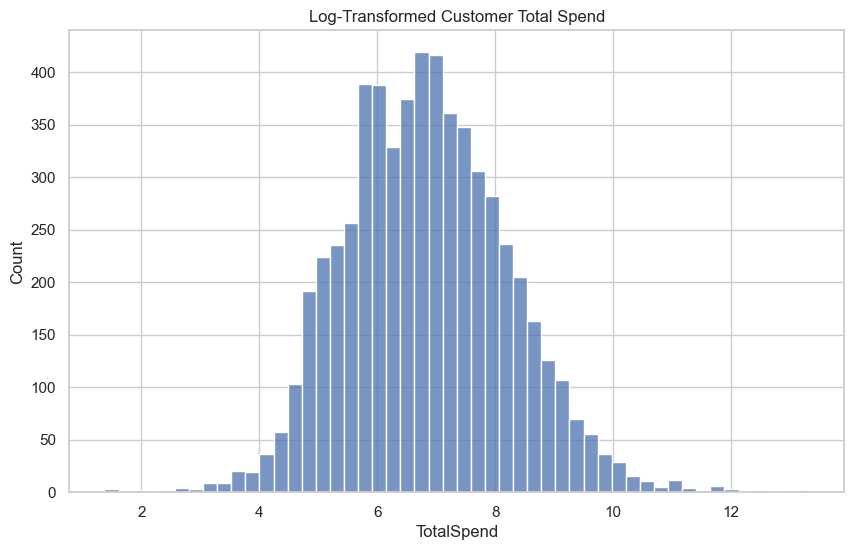

In [226]:
plt.figure()
sns.histplot(np.log1p(customer_summary['TotalSpend']), bins=50)
plt.title("Log-Transformed Customer Total Spend")

plt.savefig("../visuals/log_transformed_customer_total_spend.png", dpi=300)

log-transformed customer spend looks:

* Roughly bell-shaped

* Slight right tail

* Clear clustering in middle

<b><u>Observation</b></u>:
Customer spending is heavily skewed in raw scale but approximately normal in log scale.

  

In [227]:
customer_summary['Segment'] = pd.qcut(
    customer_summary['TotalSpend'],
    q=3,
    labels=['Low Value', 'Mid Value', 'High Value']
)

customer_summary['Segment'].value_counts()

Segment
Low Value     1960
High Value    1960
Mid Value     1958
Name: count, dtype: int64

In [228]:
segment_revenue = customer_summary.groupby('Segment', observed=False)['TotalSpend'].sum()

segment_percentage = (segment_revenue / segment_revenue.sum()) * 100

segment_percentage

Segment
Low Value      2.737890
Mid Value     10.314813
High Value    86.947297
Name: TotalSpend, dtype: float64

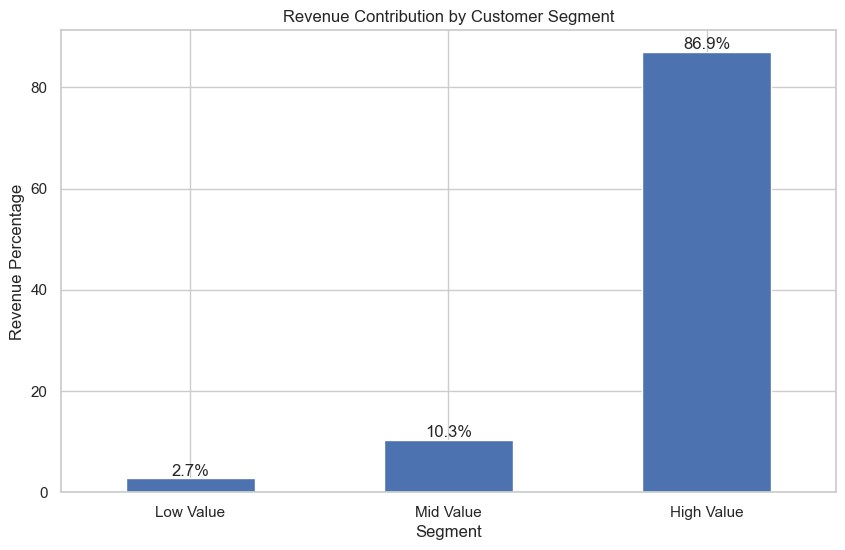

In [229]:
plt.figure()

segment_percentage.plot(kind='bar')

plt.title("Revenue Contribution by Customer Segment")
plt.ylabel("Revenue Percentage")
plt.xticks(rotation=0)

for i, value in enumerate(segment_percentage):
    plt.text(i, value, f"{value:.1f}%", ha='center', va='bottom')


plt.savefig("../visuals/segment_rev_contri.png", dpi=300)

We divided customers equally (~33% each).

But revenue distribution is:

* Bottom 33% - only 2.7% revenue

* Middle 33% - only 10.3% revenue

* Top 33% - massive 86.9% revenue

<b><u>Observations</b></u>:

1. Strong B2B or wholesale component

2. A few customers drive majority of revenue

3. Losing high-value customers would be very risky

## Step 5: Customer Segmentation Based on Spending Behavior

To understand revenue concentration and customer value distribution, customers were aggregated at the individual level using:

- **Total Spend**
- **Total Orders**
- **Total Quantity Purchased**

This allowed transformation from transaction-level data to customer-level analytics.

---

### Spend Distribution Analysis

Customer spending is highly right-skewed:

- Average customer spend ≈ £3,018  
- Median spend ≈ £899  
- Maximum spend exceeds £600,000  

This indicates that a small group of customers contributes disproportionately large revenue.

---

### Quantile-Based Segmentation

Customers were divided into three equal groups based on Total Spend:

- **Low Value**
- **Mid Value**
- **High Value**

Each segment contains roughly one-third of customers.

---

### Revenue Contribution by Segment

Revenue analysis reveals extreme concentration:

- **High Value customers (~33% of customers) contribute ~87% of total revenue**
- Mid Value customers contribute ~10%
- Low Value customers contribute ~3%

---

### Key Insight

Although customers are evenly distributed numerically across segments, revenue is heavily concentrated among High Value customers.

This indicates strong dependency on top spenders and highlights revenue concentration risk.

---

### Business Implications

- Retention strategies should prioritize High Value customers.
- Upsell strategies can target Mid Value customers.
- Low Value customers represent growth opportunity but currently contribute minimal revenue.

This preliminary segmentation establishes the foundation for deeper behavioral segmentation using RFM analysis.

<h1><u>STEP 6: RFM Segmentation</u></h1>

In [230]:
snapshot_date = df_customer['InvoiceDate'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

In [231]:
rfm = df_customer.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'Revenue': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,5633.32
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [232]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,3018.616737
std,1715.572666,209.338707,13.009406,14737.731040
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,348.762500
50%,15314.500000,96.000000,3.000000,898.915000
75%,16797.750000,380.000000,7.000000,2307.090000
max,18287.000000,739.000000,398.000000,608821.650000


### RFM Analysis – Summary Interpretation

We computed Recency, Frequency, and Monetary metrics for 5,878 unique customers.

####  Recency (Days Since Last Purchase)
- Average recency: ~201 days  
- Median recency: 96 days  
- Maximum recency: 739 days  

**Interpretation:**  
A large proportion of customers have not purchased recently. The wide spread suggests a mix of active and potentially churned customers.

---

#### Frequency (Number of Orders)
- Average frequency: ~6 orders  
- Median frequency: 3 orders  
- Maximum frequency: 398 orders  

**Interpretation:**  
Most customers purchase infrequently (1–3 orders), while a small group of highly active customers place a very large number of orders.

---

#### Monetary (Total Spend)
- Average spend: ~£3,018  
- Median spend: ~£899  
- Maximum spend: ~£608,822  

**Interpretation:**  
Customer spending is highly right-skewed. A small number of high-value customers contribute disproportionately large revenue.

---

###  Overall Insight

The RFM metrics confirm strong customer heterogeneity:
- Many low-frequency, low-spend customers
- A small but highly valuable segment driving revenue
- Significant opportunity for retention and re-engagement strategies

This sets the foundation for customer scoring and segmentation.

In [233]:
# Recency score (lower recency = higher score)
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

# Frequency score (higher frequency = higher score)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])

# Monetary score (higher spend = higher score)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [234]:
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,12346.0,326,12,77556.46,2,5,5,255
1,12347.0,2,8,5633.32,5,4,5,545
2,12348.0,75,5,2019.40,3,4,4,344
3,12349.0,19,4,4428.69,5,3,5,535
4,12350.0,310,1,334.40,2,1,2,212


In [235]:
rfm['RFM_Score'].value_counts().head()

RFM_Score
555    474
111    320
455    249
121    173
344    167
Name: count, dtype: int64

In [236]:
def rfm_segment(row):
    if row['R_score'] == 5 and row['F_score'] >= 4:
        return 'Champions'
    elif row['R_score'] >= 4 and row['F_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] >= 3 and row['F_score'] >= 2:
        return 'Potential Loyalist'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'Lost'
    else:
        return 'Others'

rfm['Customer_Segment'] = rfm.apply(rfm_segment, axis=1)

rfm['Customer_Segment'].value_counts()

Customer_Segment
Lost                  1523
Potential Loyalist    1250
Loyal Customers       1084
Champions              837
At Risk                824
Others                 360
Name: count, dtype: int64

In [237]:
segment_revenue = rfm.merge(customer_summary, on='CustomerID')

segment_revenue = segment_revenue.groupby('Customer_Segment')['TotalSpend'].sum()

segment_percentage = (segment_revenue / segment_revenue.sum()) * 100

segment_percentage.sort_values(ascending=False)

Customer_Segment
Champions             51.423237
Loyal Customers       20.601008
Potential Loyalist    14.226626
At Risk                9.208905
Lost                   3.759825
Others                 0.780399
Name: TotalSpend, dtype: float64

### Revenue Contribution by RFM Segment

After classifying customers into behavioral segments using RFM scoring, we analyzed the revenue contribution of each segment.

#### Revenue Distribution by Segment

- **Champions:** 51.42%
- **Loyal Customers:** 20.60%
- **Potential Loyalists:** 14.23%
- **At Risk:** 9.21%
- **Lost:** 3.76%
- **Others:** 0.78%

---

### Key Insights

1. **Champions alone contribute over 50% of total revenue**, despite representing a much smaller share of total customers.
2. **Champions + Loyal Customers together generate ~72% of total revenue**, indicating strong revenue concentration among high-engagement customers.
3. The **Lost segment contributes less than 4% of revenue**, confirming that inactive customers have minimal financial impact.
4. The **At Risk segment still contributes over 9%**, suggesting meaningful revenue is at potential risk if these customers are not retained.

---

### Business Implications

- The business is highly dependent on its top-performing customers.
- Retention strategies for Champions and Loyal Customers should be prioritized.
- Re-engagement campaigns targeting At Risk customers could prevent significant revenue loss.
- Upselling and engagement strategies can convert Potential Loyalists into Loyal or Champion customers.

---

### Strategic Recommendation

Customer retention and loyalty initiatives should focus on protecting and nurturing the top two segments (Champions and Loyal Customers), as they collectively drive the majority of revenue. Proactive monitoring of the At Risk segment can further reduce churn-related revenue decline.

<h1><u>STEP 7: Cohort Retention</u></h1>

In [238]:
# Create YearMonth for transactions
df_customer['YearMonth'] = df_customer['InvoiceDate'].dt.to_period('M')

# First purchase month per customer
df_customer['CohortMonth'] = df_customer.groupby('Customer ID')['YearMonth'].transform('min')

df_customer[['Customer ID','YearMonth','CohortMonth']].head()

,Customer ID,YearMonth,CohortMonth
0,13085.0,2009-12,2009-12
1,13085.0,2009-12,2009-12
2,13085.0,2009-12,2009-12
3,13085.0,2009-12,2009-12
4,13085.0,2009-12,2009-12


In [ ]:
def get_month_diff(row):
    return (row['YearMonth'].year - row['CohortMonth'].year) * 12 + \
           (row['YearMonth'].month - row['CohortMonth'].month)

df_customer['CohortIndex'] = df_customer.apply(get_month_diff, axis=1)

df_customer[['Customer ID','YearMonth','CohortMonth','CohortIndex']].head()

In [ ]:
cohort_data = df_customer.groupby(['CohortMonth','CohortIndex'])['Customer ID'].nunique().reset_index()

cohort_counts = cohort_data.pivot(index='CohortMonth',
                                   columns='CohortIndex',
                                   values='Customer ID')

cohort_sizes = cohort_counts.iloc[:,0]

retention = cohort_counts.divide(cohort_sizes, axis=0)

retention.head()

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="viridis"
)

plt.title("Cohort Retention Analysis")
plt.ylabel("Cohort Month")
plt.xlabel("Months Since First Purchase")


plt.savefig("../visuals/heatmap.png", dpi=300)

### Cohort Retention Analysis – Key Findings

The cohort retention heatmap tracks customer return behavior month-over-month after their first purchase.

---

### Observed Retention Pattern

1. **Sharp Drop After First Month**
   - Most cohorts experience a significant drop from 100% (month 0) to approximately 15–35% in month 1.
   - This indicates that a large proportion of customers do not make a second purchase immediately.

2. **Gradual Decline Over Time**
   - After month 1, retention continues to decline steadily.
   - By months 6–12, retention typically falls below 10–20% for most cohorts.

3. **Strong Early Cohorts**
   - Earlier cohorts (2009–2010) show slightly stronger long-term retention compared to later cohorts.
   - This may indicate stronger early customer loyalty or changes in acquisition strategy over time.

4. **Retention Stabilization**
   - After several months, retention appears to stabilize at a low baseline (around 5–10%).
   - This likely represents a core group of loyal repeat customers.

---

###  Business Interpretation

- The business experiences **high customer acquisition but moderate retention**.
- A significant percentage of customers make only one purchase.
- Long-term revenue sustainability depends on a relatively small group of repeat buyers.
- Improving second-purchase conversion could significantly increase lifetime value.

---

### Strategic Recommendations

- Implement post-purchase engagement campaigns to encourage second purchases.
- Offer incentives (discounts, loyalty points) within 30 days of first purchase.
- Identify high-retention cohorts and replicate acquisition channels or marketing strategies used during those periods.
- Develop targeted retention strategies for cohorts with lower repeat rates.

---

###  Overall Insight

The cohort analysis confirms that while the business successfully acquires customers, long-term retention declines rapidly. Strengthening customer retention strategies could significantly enhance lifetime value and revenue stability.

<h1><u>STEP 8: Return Analysis</u></h1>

In [ ]:
# Identify return transactions
df_returns = df[df['Quantity'] < 0].copy()

df_returns['ReturnAmount'] = df_returns['Quantity'] * df_returns['Price']

df_returns.shape

In [ ]:
# % of Transactions That Are Returns
total_transactions = df.shape[0]
return_transactions = df_returns.shape[0]

(return_transactions / total_transactions) * 100

In [ ]:
# What % of total revenue is impacted by returns
total_revenue = (df[(df['Quantity'] > 0) & (df['Price'] > 0)]
                 .assign(Revenue=lambda x: x['Quantity'] * x['Price']))['Revenue'].sum()

total_return_value = abs(df_returns['ReturnAmount'].sum())

return_impact_percentage = (total_return_value / total_revenue) * 100

return_impact_percentage

### Returns Analysis – Key Findings

We analyzed negative quantity transactions to understand return behavior.

#### Return Volume
- Total return transactions: 22,950
- Returns account for approximately 2.15% of all transactions.

#### Revenue Impact
- Returns impact approximately 7.28% of total revenue.

---

### Interpretation

Although return transactions represent a relatively small proportion of total orders (2.15%), they have a disproportionately higher impact on revenue (7.28%).

This suggests that returned transactions tend to involve higher-value purchases.

---

### Business Implications

- Return management is critical, especially for higher-value products.
- Even a small increase in return rate could significantly affect profitability.
- Monitoring product-level return rates could help identify quality or expectation issues.
- Improving product descriptions and customer communication may reduce return frequency.

---

### Strategic Insight

Return rates appear operationally manageable (<5% of transactions), but the revenue exposure (~7%) indicates that high-value items are more likely to be returned. Targeted quality control and return policy optimization could reduce revenue leakage.